# Ejercicio propuesto

- Crea un programa llamado ParquesEolicosProvinciaGrafico.py que utilice el archivo CSV que se te proporciona sobre parques eólicos de la comunidad de Castilla y León.
- Nos interesa saber la potencia total media de los parques eólicos por provincia, pero algunas potencias totales no están disponibles.
- Deberás asignarles como valor la moda, y luego mostrar un gráfico de barras resultado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_parques = pd.read_csv("parques_eolicos2.csv", sep=';')
df_parques.head()

,num,nombre,municipio,provincia,potencia,tecnologia,aerogeneradores,potencia_unitaria
0,225.0,Aerogenerador Experimental I+D G-87,Lubián,ZA,2000.0,GAMESA,1,2000
1,226.0,Aerogenerador Experimental I+D G-90,Lubián,ZA,NaN,GAMESA,1,2000
2,162.0,Ágreda,Agreda,SO,18000.0,ACCIONA,12,1500
3,153.0,ALBA DE TORMES,Alba de Tormes,SA,NaN,MTORRES,3,1500
4,108.0,Alconada,Ampudia,PA,4500.0,ACCIONA,3,1500


In [3]:
print(f"Cantidad de datos nulos:\n{df_parques.isnull().sum()}")

Cantidad de datos nulos:
num                   0
nombre                0
municipio             0
provincia             0
potencia             20
tecnologia            0
aerogeneradores       0
potencia_unitaria     0
dtype: int64


In [4]:
moda_potencia = df_parques['potencia'].mode()[0]
print(f"Moda 'potencia': {moda_potencia}")

Moda 'potencia': 18000.0


In [5]:
df_parques['potencia'] = df_parques['potencia'].fillna(moda_potencia)
df_parques.head()

,num,nombre,municipio,provincia,potencia,tecnologia,aerogeneradores,potencia_unitaria
0,225.0,Aerogenerador Experimental I+D G-87,Lubián,ZA,2000.0,GAMESA,1,2000
1,226.0,Aerogenerador Experimental I+D G-90,Lubián,ZA,18000.0,GAMESA,1,2000
2,162.0,Ágreda,Agreda,SO,18000.0,ACCIONA,12,1500
3,153.0,ALBA DE TORMES,Alba de Tormes,SA,18000.0,MTORRES,3,1500
4,108.0,Alconada,Ampudia,PA,4500.0,ACCIONA,3,1500


In [6]:
media_por_provincia = df_parques.groupby('provincia')['potencia'].mean()
media_por_provincia

,potencia
provincia,
AV,17378.666667
BU,26394.763158
LE,27871.875000
PA,17865.340909
SA,25591.428571
SG,25240.000000
SO,27443.333333
VA,37310.263158
ZA,21952.142857


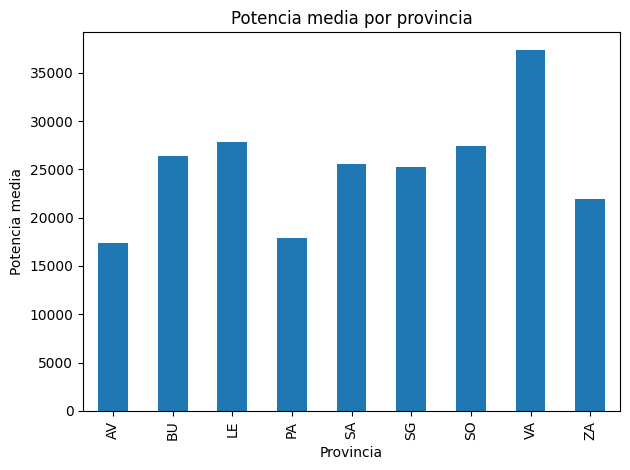

In [7]:
media_por_provincia.plot.bar()

plt.xlabel('Provincia')
plt.ylabel('Potencia media')
plt.title('Potencia media por provincia')
plt.tight_layout()
plt.show()